graph 1

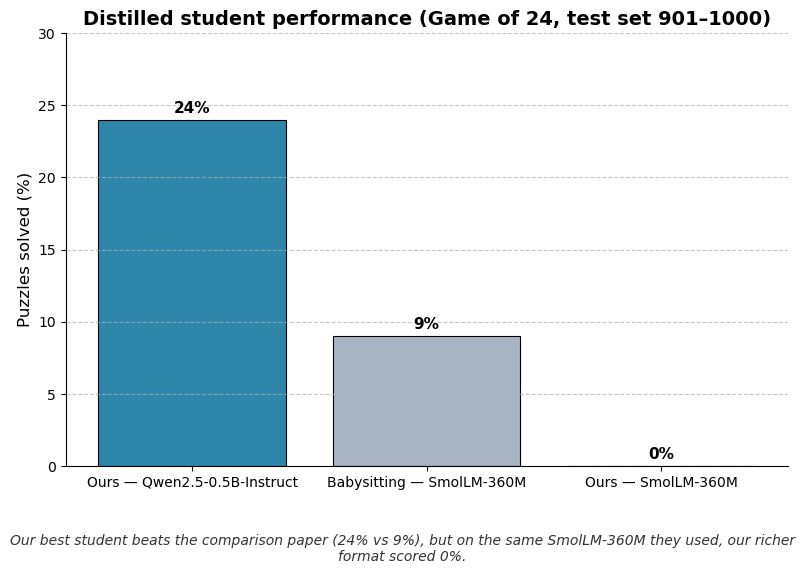

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["Ours — Qwen2.5-0.5B-Instruct", "Babysitting — SmolLM-360M", "Ours — SmolLM-360M"]
values = [24, 9, 0]
colors = ["#2E86AB", "#A9B4C2", "#C44B4B"]  # ours highlight, grey, muted red

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars
bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Set y-axis limits and label
ax.set_ylim(0, 30)
ax.set_ylabel("Puzzles solved (%)", fontsize=12)
ax.set_title("Distilled student performance (Game of 24, test set 901–1000)", fontsize=14, fontweight='bold')

# Optional: add a light grid on y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Rotate x-axis labels slightly if needed (optional, but categories are short)
plt.xticks(rotation=0, ha='center')

# Add caption / note below the plot
caption = ("Our best student beats the comparison paper (24% vs 9%), but on the same SmolLM-360M they used, "
           "our richer format scored 0%.")
fig.text(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=10, color='#333333', style='italic')

# Adjust layout to make room for caption
plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # leave bottom 10% for caption

# Show plot (or use plt.savefig('graph1.png', dpi=300) to save)
plt.show()

graph  3

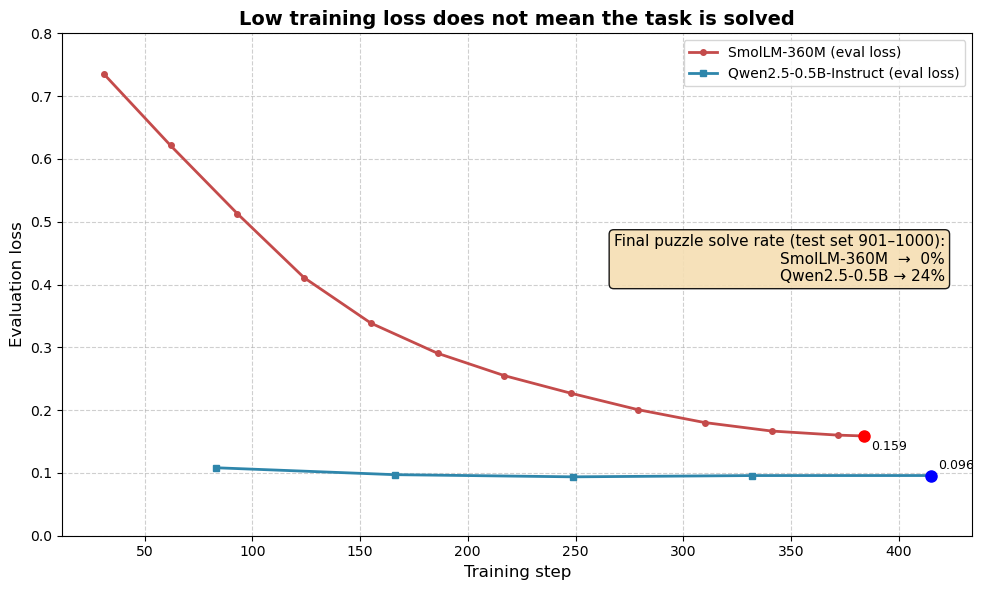

In [12]:
import json
import matplotlib.pyplot as plt

# Load JSON data
with open("smollm_training_logs_final.json", "r") as f:
    smollm_data = json.load(f)

with open("training_logs_qwen05 - try1.json", "r") as f:
    qwen_data = json.load(f)

# Extract eval_loss and step for SmolLM
smollm_steps = []
smollm_eval_loss = []
for entry in smollm_data:
    if "eval_loss" in entry:
        smollm_steps.append(entry["step"])
        smollm_eval_loss.append(entry["eval_loss"])

# Extract eval_loss and step for Qwen
qwen_steps = []
qwen_eval_loss = []
for entry in qwen_data:
    if "eval_loss" in entry:
        qwen_steps.append(entry["step"])
        qwen_eval_loss.append(entry["eval_loss"])

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot lines
ax.plot(smollm_steps, smollm_eval_loss, 
        marker='o', markersize=4, linewidth=2, 
        color='#C44B4B', label='SmolLM-360M (eval loss)')
ax.plot(qwen_steps, qwen_eval_loss, 
        marker='s', markersize=4, linewidth=2, 
        color='#2E86AB', label='Qwen2.5-0.5B-Instruct (eval loss)')

# Labels and title
ax.set_xlabel("Training step", fontsize=12)
ax.set_ylabel("Evaluation loss", fontsize=12)
ax.set_title("Low training loss does not mean the task is solved", fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.grid(True, linestyle='--', alpha=0.6)

# Annotation box (positioned lower right, below legend)
solve_text = (
    "Final puzzle solve rate (test set 901–1000):\n"
    "SmolLM-360M  →  0%\n"
    "Qwen2.5-0.5B → 24%"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
# Place box at top-right but with offset (x=0.97, y=0.6) – adjust y as needed
ax.text(0.97, 0.6, solve_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

# Legend at top-right (higher)
ax.legend(loc='upper right', fontsize=10)  # This will automatically place at top-right corner

# Mark final points with annotations
ax.plot(smollm_steps[-1], smollm_eval_loss[-1], 'ro', markersize=8, label='_nolegend_')
ax.plot(qwen_steps[-1], qwen_eval_loss[-1], 'bo', markersize=8, label='_nolegend_')
ax.annotate(f"{smollm_eval_loss[-1]:.3f}", 
            xy=(smollm_steps[-1], smollm_eval_loss[-1]),
            xytext=(5, -10), textcoords='offset points', fontsize=9)
ax.annotate(f"{qwen_eval_loss[-1]:.3f}", 
            xy=(qwen_steps[-1], qwen_eval_loss[-1]),
            xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

graph 4

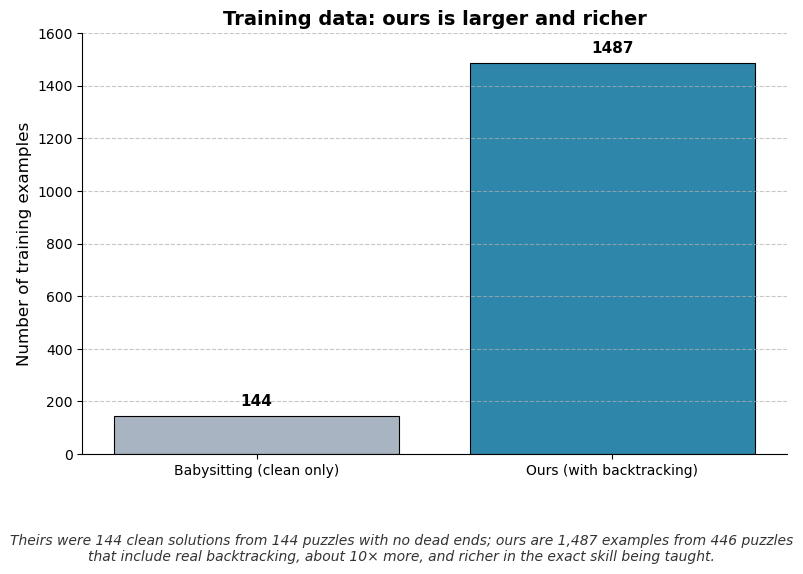

In [13]:
import matplotlib.pyplot as plt

# Data
categories = ["Babysitting (clean only)", "Ours (with backtracking)"]
values = [144, 1487]
colors = ["#A9B4C2", "#2E86AB"]  # grey for babysitting, highlight for ours

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars
bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Set y-axis limit and label
ax.set_ylim(0, 1600)
ax.set_ylabel("Number of training examples", fontsize=12)
ax.set_title("Training data: ours is larger and richer", fontsize=14, fontweight='bold')

# Optional: light grid on y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add caption / note below the plot
caption = ("Theirs were 144 clean solutions from 144 puzzles with no dead ends; ours are 1,487 examples from 446 puzzles "
           "that include real backtracking, about 10× more, and richer in the exact skill being taught.")
fig.text(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=10, color='#333333', style='italic')

# Adjust layout to make room for caption
plt.tight_layout(rect=[0, 0.12, 1, 0.95])  # leave bottom 12% for caption

# Show plot (or use plt.savefig('graph4.png', dpi=300))
plt.show()

graph 2

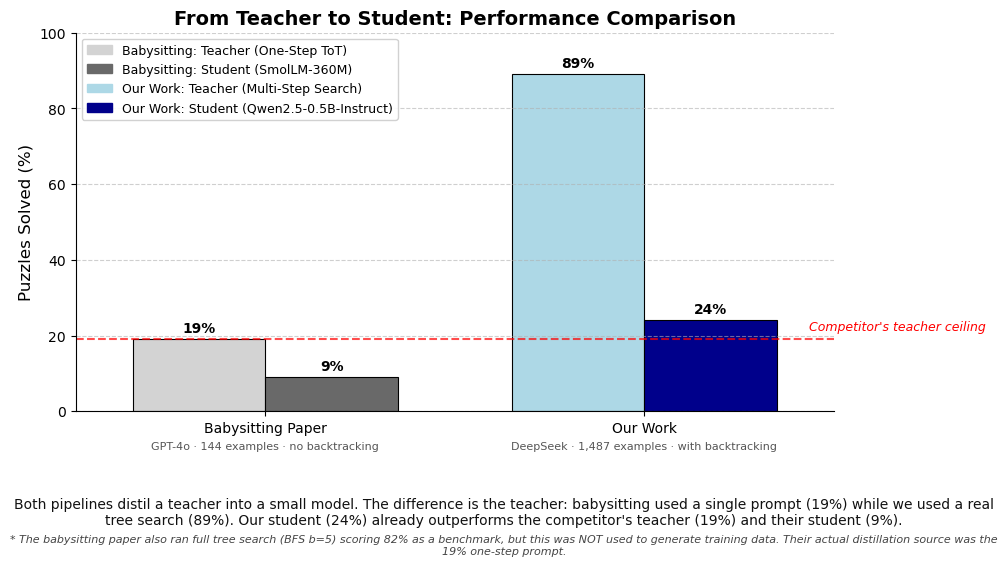

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
groups = ['Babysitting Paper', 'Our Work']
teacher_values = [19, 89]
student_values = [9, 24]

# Colors
teacher_colors = ['#D3D3D3', '#ADD8E6']   # light grey, light blue
student_colors = ['#696969', '#00008B']   # dark grey, dark blue

# Notes under each group
group_notes = [
    "GPT-4o · 144 examples · no backtracking",
    "DeepSeek · 1,487 examples · with backtracking"
]

# Bar positions
x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars (no labels in bar call, we'll use custom legend)
bars1 = ax.bar(x - width/2, teacher_values, width, color=teacher_colors, edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, student_values, width, color=student_colors, edgecolor='black', linewidth=0.8)

# Add value labels on top of bars
for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

# Add small notes below each group
ax.set_xlim(-0.5, len(groups)-0.5)
for i, note in enumerate(group_notes):
    ax.text(i, -10, note, ha='center', fontsize=8, color='#555555', transform=ax.transData)

# Dashed horizontal line at y = 19%
ax.axhline(y=19, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(len(groups)-0.1, 19 + 1.5, "Competitor's teacher ceiling",
        ha='right', va='bottom', fontsize=9, color='red', style='italic',
        transform=ax.transData)

# Y-axis and labels
ax.set_ylim(0, 100)
ax.set_ylabel("Puzzles Solved (%)", fontsize=12)
ax.set_title("From Teacher to Student: Performance Comparison", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(groups)

# Custom legend (explicit entries for each bar)
legend_elements = [
    mpatches.Patch(color='#D3D3D3', label='Babysitting: Teacher (One-Step ToT)'),
    mpatches.Patch(color='#696969', label='Babysitting: Student (SmolLM-360M)'),
    mpatches.Patch(color='#ADD8E6', label='Our Work: Teacher (Multi-Step Search)'),
    mpatches.Patch(color='#00008B', label='Our Work: Student (Qwen2.5-0.5B-Instruct)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

# Grid and spines
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Footnote
footnote = ("* The babysitting paper also ran full tree search (BFS b=5) scoring 82% as a benchmark, "
            "but this was NOT used to generate training data. Their actual distillation source was the 19% one-step prompt.")
fig.text(0.5, 0.02, footnote, wrap=True, horizontalalignment='center', fontsize=8, color='#444444', style='italic')

# Main caption
caption = ("Both pipelines distil a teacher into a small model. The difference is the teacher: "
           "babysitting used a single prompt (19%) while we used a real tree search (89%). "
           "Our student (24%) already outperforms the competitor's teacher (19%) and their student (9%).")
fig.text(0.5, 0.07, caption, wrap=True, horizontalalignment='center', fontsize=10, color='#111111')

# Adjust layout
plt.tight_layout(rect=[0, 0.15, 1, 0.95])

plt.show()
# To save: plt.savefig('graph2_main.png', dpi=300)

graph 5

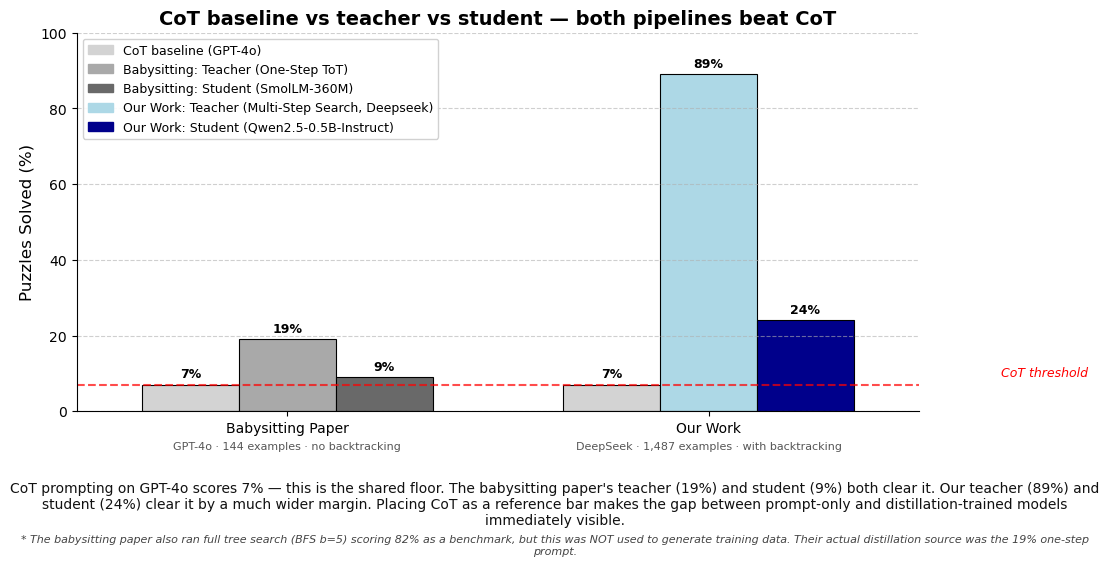

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data
groups = ['Babysitting Paper', 'Our Work']
cot_values = [7, 7]
teacher_values = [19, 89]
student_values = [9, 24]

# Colors
cot_colors = ['#D3D3D3', '#D3D3D3']           # light grey for both
teacher_colors = ['#A9A9A9', '#ADD8E6']       # medium grey (babysitting) / light blue (ours)
student_colors = ['#696969', '#00008B']       # dark grey / dark blue

# Notes under each group (same as Graph 2)
group_notes = [
    "GPT-4o · 144 examples · no backtracking",
    "DeepSeek · 1,487 examples · with backtracking"
]

# Bar positions (three bars per group)
x = np.arange(len(groups))
width = 0.23                     # narrower to fit three bars

fig, ax = plt.subplots(figsize=(11, 6))

# Plot bars: CoT (left), Teacher (center), Student (right)
bars_cot = ax.bar(x - width, cot_values, width, color=cot_colors, edgecolor='black', linewidth=0.8)
bars_teacher = ax.bar(x, teacher_values, width, color=teacher_colors, edgecolor='black', linewidth=0.8)
bars_student = ax.bar(x + width, student_values, width, color=student_colors, edgecolor='black', linewidth=0.8)

# Add value labels on top of each bar
for bar_set in [bars_cot, bars_teacher, bars_student]:
    for bar in bar_set:
        h = bar.get_height()
        ax.annotate(f'{h}%', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add small notes below each group (under x-axis labels)
ax.set_xlim(-0.5, len(groups)-0.5)
for i, note in enumerate(group_notes):
    ax.text(i, -10, note, ha='center', fontsize=8, color='#555555', transform=ax.transData)

# Dashed horizontal line at y = 7% (CoT threshold)
ax.axhline(y=7, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(len(groups)-0.1, 7 + 1.5, "CoT threshold",
        ha='right', va='bottom', fontsize=9, color='red', style='italic',
        transform=ax.transData)

# Y-axis and labels
ax.set_ylim(0, 100)
ax.set_ylabel("Puzzles Solved (%)", fontsize=12)
ax.set_title("CoT baseline vs teacher vs student — both pipelines beat CoT", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(groups)

# Custom legend – explains all six bars
legend_elements = [
    mpatches.Patch(color='#D3D3D3', label='CoT baseline (GPT-4o)'),
    mpatches.Patch(color='#A9A9A9', label='Babysitting: Teacher (One-Step ToT)'),
    mpatches.Patch(color='#696969', label='Babysitting: Student (SmolLM-360M)'),
    mpatches.Patch(color='#ADD8E6', label='Our Work: Teacher (Multi-Step Search, Deepseek)'),
    mpatches.Patch(color='#00008B', label='Our Work: Student (Qwen2.5-0.5B-Instruct)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

# Grid and spines
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Footnote (small text, placed below caption)
footnote = ("* The babysitting paper also ran full tree search (BFS b=5) scoring 82% as a benchmark, "
            "but this was NOT used to generate training data. Their actual distillation source was the 19% one-step prompt.")
fig.text(0.5, 0.02, footnote, wrap=True, horizontalalignment='center', fontsize=8, color='#444444', style='italic')

# Main caption
caption = ("CoT prompting on GPT-4o scores 7% — this is the shared floor. The babysitting paper's teacher (19%) "
           "and student (9%) both clear it. Our teacher (89%) and student (24%) clear it by a much wider margin. "
           "Placing CoT as a reference bar makes the gap between prompt-only and distillation-trained models immediately visible.")
fig.text(0.5, 0.07, caption, wrap=True, horizontalalignment='center', fontsize=10, color='#111111')

# Adjust layout to leave space at bottom for caption and footnote
plt.tight_layout(rect=[0, 0.15, 1, 0.95])

plt.show()
# Uncomment to save: plt.savefig('graph5_cot_baseline.png', dpi=300)